In [3]:
import pandas as pd
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import os
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout,UpSampling2D, LeakyReLU, BatchNormalization
from tensorflow.keras.utils import plot_model
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, models


### load the dataset

In [4]:
df_train = pd.read_csv("/kaggle/input/datasets/meowmeowmeowmeowmeow/gtsrb-german-traffic-sign/Train.csv")
df_test = pd.read_csv("/kaggle/input/datasets/meowmeowmeowmeowmeow/gtsrb-german-traffic-sign/Train.csv")


### basic Info

In [5]:
df_train.shape

(39209, 8)

In [6]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 39209 entries, 0 to 39208
Data columns (total 8 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   Width    39209 non-null  int64 
 1   Height   39209 non-null  int64 
 2   Roi.X1   39209 non-null  int64 
 3   Roi.Y1   39209 non-null  int64 
 4   Roi.X2   39209 non-null  int64 
 5   Roi.Y2   39209 non-null  int64 
 6   ClassId  39209 non-null  int64 
 7   Path     39209 non-null  object
dtypes: int64(7), object(1)
memory usage: 2.4+ MB


In [6]:
df_train.head()

,Width,Height,Roi.X1,Roi.Y1,Roi.X2,Roi.Y2,ClassId,Path
0,27,26,5,5,22,20,20,Train/20/00020_00000_00000.png
1,28,27,5,6,23,22,20,Train/20/00020_00000_00001.png
2,29,26,6,5,24,21,20,Train/20/00020_00000_00002.png
3,28,27,5,6,23,22,20,Train/20/00020_00000_00003.png
4,28,26,5,5,23,21,20,Train/20/00020_00000_00004.png


In [7]:
df_train.describe()

,Width,Height,Roi.X1,Roi.Y1,Roi.X2,Roi.Y2,ClassId
count,39209.000000,39209.000000,39209.000000,39209.000000,39209.000000,39209.000000,39209.000000
mean,50.835880,50.328930,5.999515,5.962381,45.197302,44.728379,15.788390
std,24.306933,23.115423,1.475493,1.385440,23.060157,21.971145,12.013238
min,25.000000,25.000000,0.000000,5.000000,20.000000,20.000000,0.000000
25%,35.000000,35.000000,5.000000,5.000000,29.000000,30.000000,5.000000
50%,43.000000,43.000000,6.000000,6.000000,38.000000,38.000000,12.000000
75%,58.000000,58.000000,6.000000,6.000000,53.000000,52.000000,25.000000
max,243.000000,225.000000,20.000000,20.000000,223.000000,205.000000,42.000000


### variable Distributions|

<Axes: xlabel='Width', ylabel='Count'>

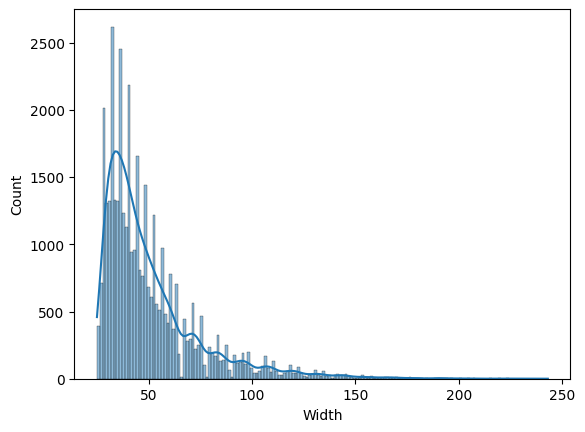

In [7]:
sns.histplot(data = df_train, x = 'Width', kde = True)

<Axes: xlabel='Height', ylabel='Count'>

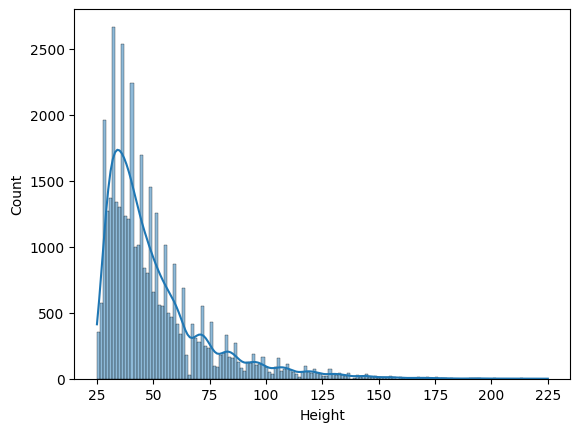

In [8]:
sns.histplot(data = df_train, x = 'Height', kde = True)

Text(0, 0.5, 'Count')

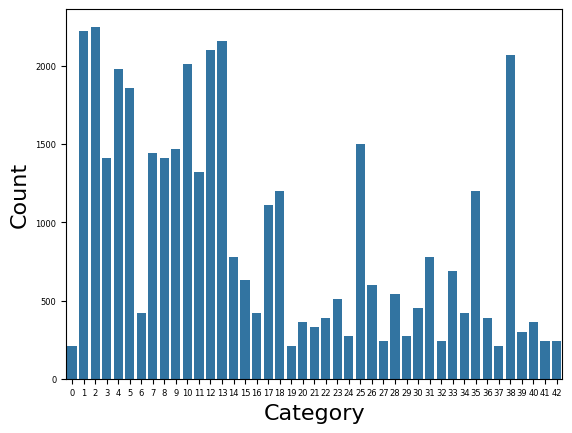

In [9]:
ax = sns.countplot(data = df_train, x = 'ClassId')
ax.tick_params(axis='both', labelsize=6)
ax.set_xlabel('Category', fontsize=16)
ax.set_ylabel('Count', fontsize=16)

In [10]:
value_count = df_train['ClassId'].value_counts() / len(df_train)
print(value_count.sort_values(ascending= False))

ClassId
2     0.057385
1     0.056620
13    0.055089
12    0.053559
38    0.052794
10    0.051264
4     0.050499
5     0.047438
25    0.038257
9     0.037491
7     0.036726
3     0.035961
8     0.035961
11    0.033666
35    0.030605
18    0.030605
17    0.028310
14    0.019893
31    0.019893
33    0.017572
15    0.016068
26    0.015303
28    0.013772
23    0.013007
30    0.011477
6     0.010712
16    0.010712
34    0.010712
22    0.009947
36    0.009947
20    0.009182
40    0.009182
21    0.008416
39    0.007651
29    0.006886
24    0.006886
42    0.006121
32    0.006121
27    0.006121
41    0.006121
0     0.005356
19    0.005356
37    0.005356
Name: count, dtype: float64


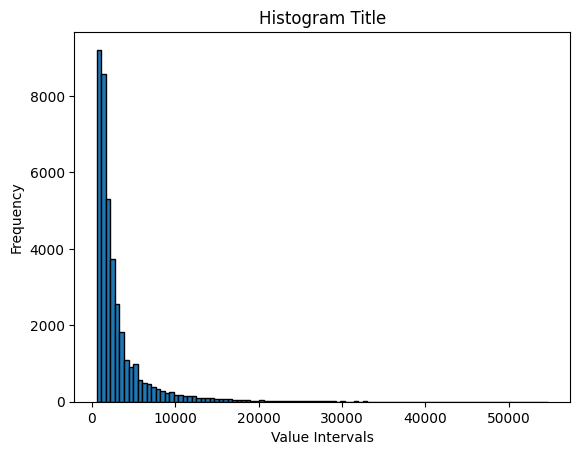

In [11]:
plt.hist(df_train["Height"]*df_train["Width"], bins=100, edgecolor='black')
plt.title('Histogram Title')
plt.xlabel('Value Intervals')
plt.ylabel('Frequency')
plt.show()

### Load Images

In [12]:
base_path = "/kaggle/input/datasets/meowmeowmeowmeowmeow/gtsrb-german-traffic-sign"
def load_images(df, target_size=(32, 32)):
    images = []
    labels = []
    for idx in range(df.shape[0]):
        roi = df.iloc[idx,2:6]
        img_path = os.path.join(base_path,df.loc[idx,"Path"])
        with Image.open(img_path) as img:
            crop_box = (roi["Roi.X1"],roi["Roi.Y1"],roi["Roi.X2"],roi["Roi.Y2"])
            img = img.crop(crop_box)
            img = img.resize(target_size)
            images.append(img)
            labels.append(df.loc[idx,"ClassId"])
    return np.array(images), np.array(labels)


In [13]:
X_train,y_train = load_images(df_train)
X_test,y_test = load_images(df_test)

In [15]:
print(len(X_train), len(y_train))

39209 39209


### Sample Img per class

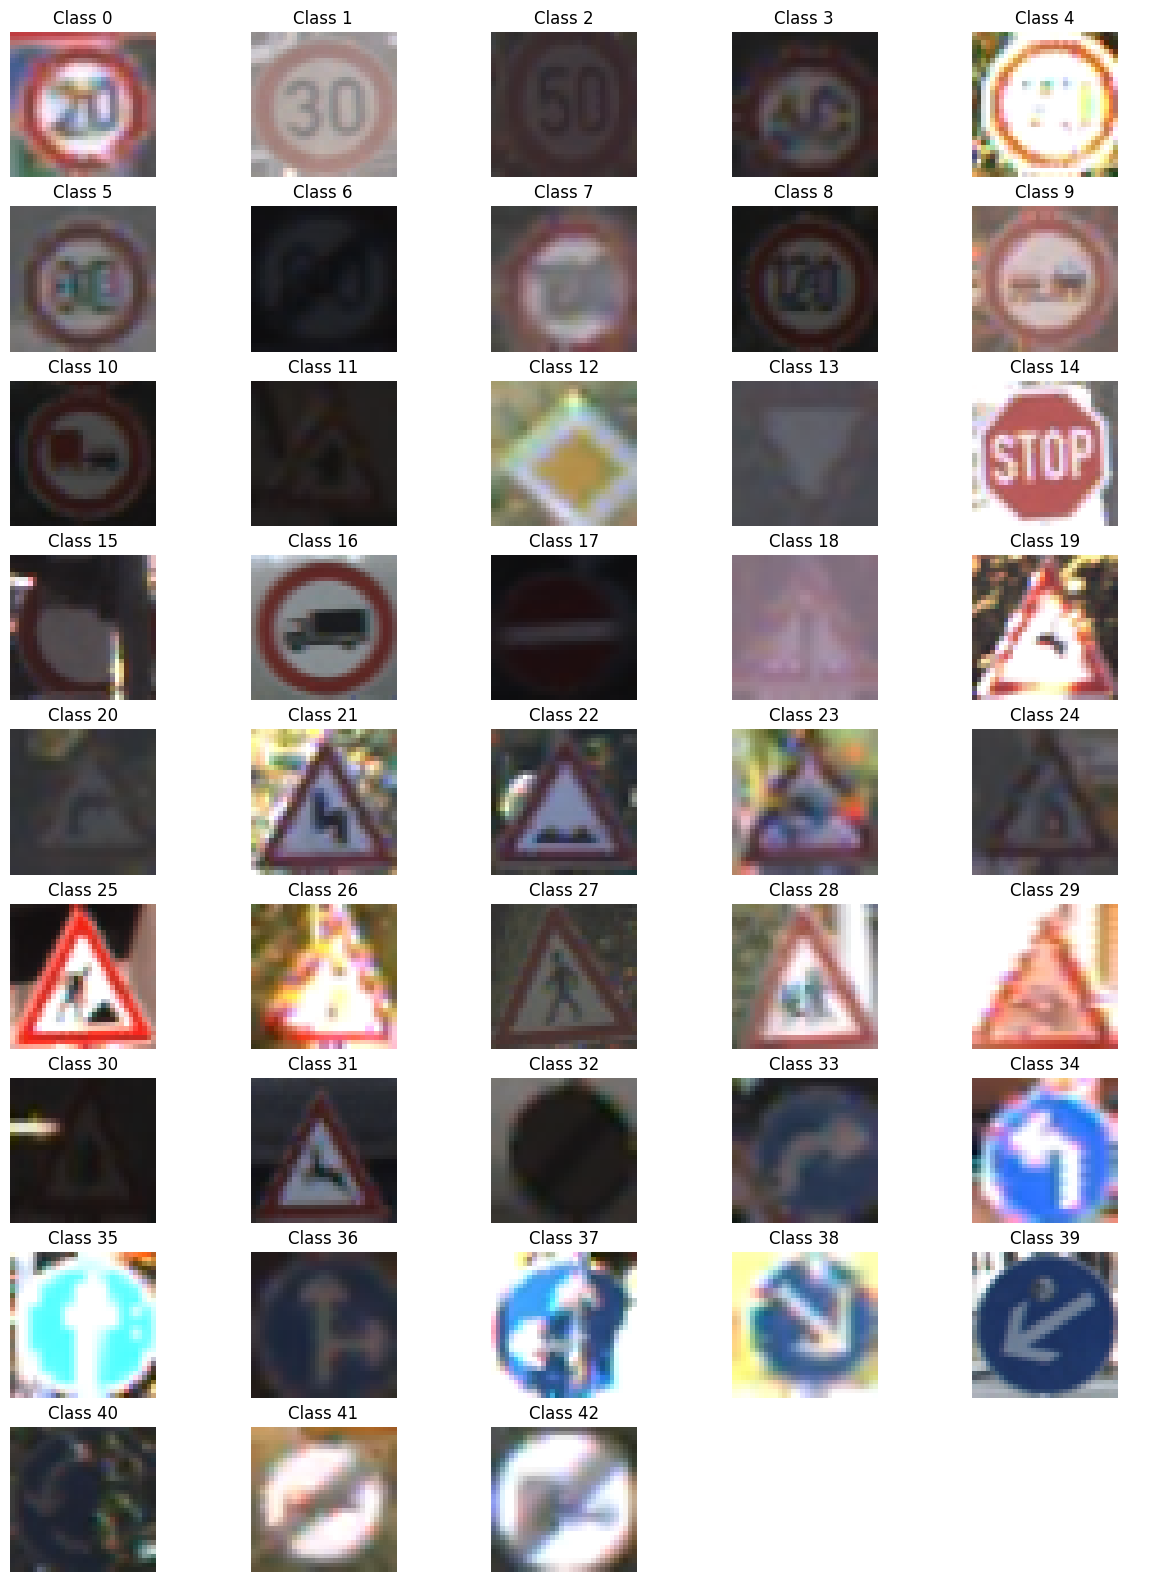

In [14]:
fig, axes = plt.subplots(9, 5, figsize= (15, 20))
for i, ax in enumerate(axes.flatten()):
  if i > 42:
    ax.axis('off')
    continue
  img = X_train[y_train == i][0]
  ax.imshow(img)
  ax.set_title(f'Class {i}')
  ax.axis('off')

### Pixels stats

In [16]:
def pixel_stats(X):

  flatten_img = X.flatten()
  Stats = {
      'mean': [np.mean(flatten_img)],
      'median': [np.median(flatten_img)],
      'std': [np.std(flatten_img)],
      'max': [np.max(flatten_img)],
      'min': [np.min(flatten_img)],
  }
  return pd.DataFrame(Stats)

In [17]:
stats = pixel_stats(X_train)
stats = stats.T.rename(columns={0: 'value'})
print(stats)

             value
mean     85.972866
median   63.000000
std      68.114775
max     255.000000
min       0.000000


In [18]:
#Flattening
images = X_train.reshape(X_train.shape[0], -1)
labels = y_train
images = images / 255
scaler = StandardScaler()
images_scaled = scaler.fit_transform(images)

In [19]:
#PCA implementation
pca = PCA(n_components=100)
image_pca = pca.fit_transform(images_scaled)
print(image_pca.shape)

#LDA implementation
lda = LDA(n_components=2)
image_lda = lda.fit_transform(image_pca, labels)
print(image_lda.shape)

(39209, 100)
(39209, 2)


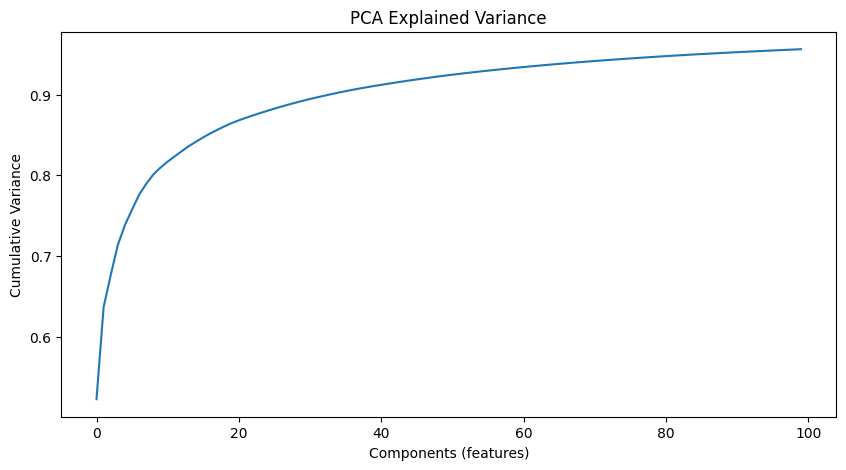

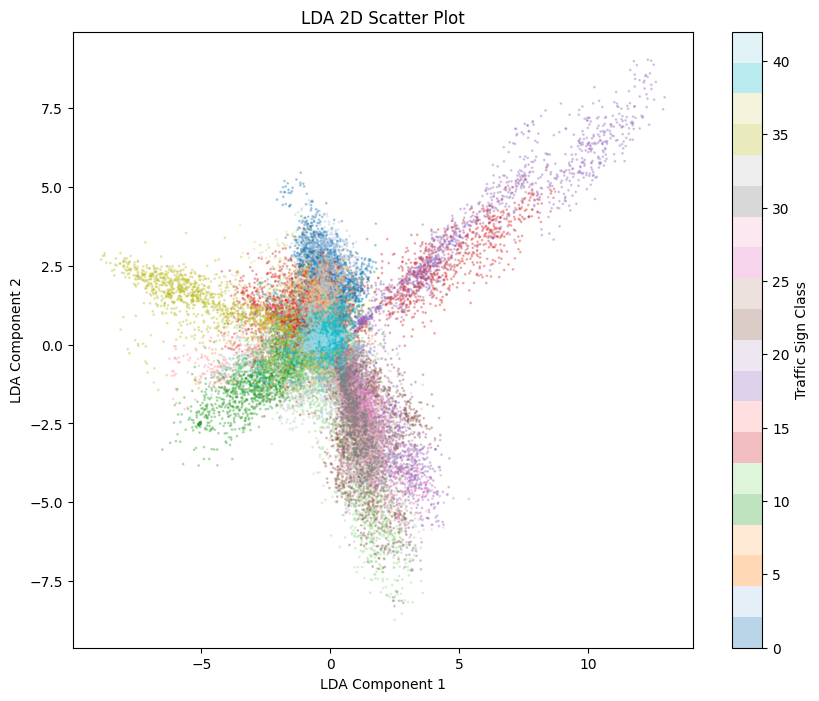

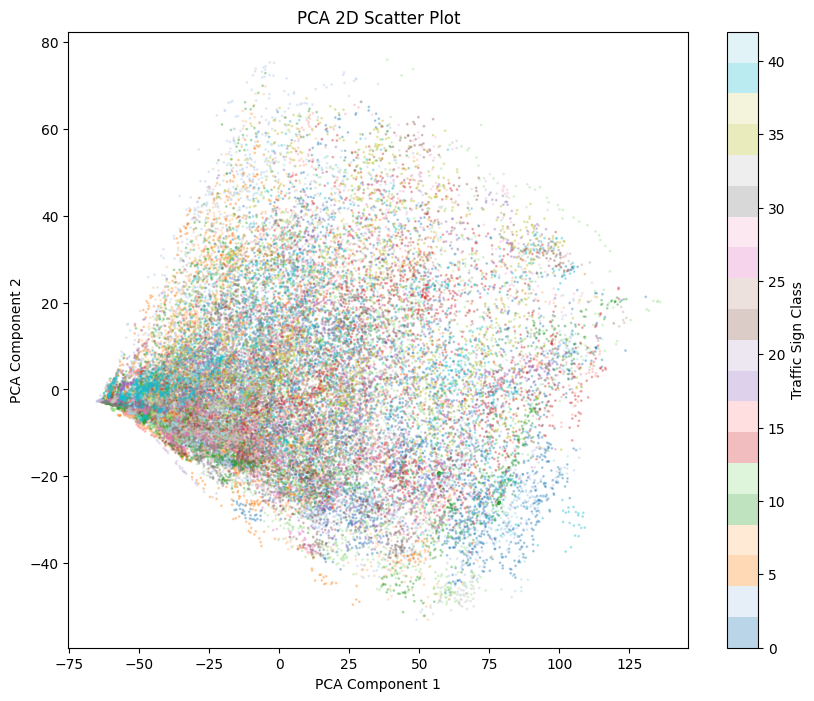

In [21]:
#Plot 1 : PCA explained variance
plt.figure(figsize=(10,5))
plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.title('PCA Explained Variance')
plt.xlabel('Components (features)')
plt.ylabel('Cumulative Variance')
plt.show()

#Plot 2 : LDA 2D Scatter Plot
plt.figure(figsize=(10,8))
plt.scatter(image_lda[:,0], image_lda[:,1], c=labels, cmap='tab20', alpha=0.3, s=1)
plt.title('LDA 2D Scatter Plot')
plt.xlabel('LDA Component 1')
plt.ylabel('LDA Component 2')
plt.colorbar(label='Traffic Sign Class')
plt.show()


#Plot 3 : PCA 2D Scatter Plot
plt.figure(figsize=(10,8))
plt.scatter(image_pca[:,0], image_pca[:,1], c=labels, cmap='tab20', alpha=0.3, s=1)
plt.title('PCA 2D Scatter Plot')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.colorbar(label='Traffic Sign Class')
plt.show()

In [22]:



# Flatten and scale test images the same way as training
X_test_flat = X_test.reshape(X_test.shape[0], -1) / 255
X_test_scaled = scaler.transform(X_test_flat)

In [23]:



# -------------------------
# 1. Naive Bayes Classifier
# -------------------------
nb_clf = GaussianNB()
nb_clf.fit(images_scaled, labels)
y_pred_nb = nb_clf.predict(X_test_scaled)

print("=== Naive Bayes Performance ===")
print("Accuracy:", accuracy_score(y_test, y_pred_nb))
print("\nClassification Report:\n", classification_report(y_test, y_pred_nb))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_nb))


=== Naive Bayes Performance ===
Accuracy: 0.228008875513275

Classification Report:
               precision    recall  f1-score   support

           0       0.11      0.75      0.19       210
           1       0.24      0.25      0.25      2220
           2       0.28      0.14      0.19      2250
           3       0.12      0.25      0.16      1410
           4       0.20      0.01      0.03      1980
           5       0.12      0.12      0.12      1860
           6       0.04      0.84      0.07       420
           7       0.19      0.21      0.20      1440
           8       0.04      0.06      0.05      1410
           9       0.86      0.23      0.36      1470
          10       0.62      0.01      0.02      2010
          11       0.83      0.08      0.14      1320
          12       1.00      0.23      0.37      2100
          13       0.64      0.44      0.52      2160
          14       0.84      0.71      0.77       780
          15       0.28      0.25      0.26       

In [24]:


# -------------------------
# 2. KNN Classifier
# -------------------------
knn_clf = KNeighborsClassifier(n_neighbors=5)  # you can tune k
knn_clf.fit(images_scaled, labels)
y_pred_knn = knn_clf.predict(X_test_scaled)

print("=== KNN Performance ===")
print("Accuracy:", accuracy_score(y_test, y_pred_knn))
print("\nClassification Report:\n", classification_report(y_test, y_pred_knn))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_knn))

=== KNN Performance ===
Accuracy: 0.9606722946262338

Classification Report:
               precision    recall  f1-score   support

           0       0.93      0.95      0.94       210
           1       0.96      0.97      0.96      2220
           2       0.96      0.95      0.95      2250
           3       0.91      0.91      0.91      1410
           4       0.95      0.96      0.95      1980
           5       0.87      0.94      0.91      1860
           6       0.99      1.00      0.99       420
           7       0.94      0.96      0.95      1440
           8       0.93      0.97      0.95      1410
           9       0.99      0.96      0.98      1470
          10       0.98      0.96      0.97      2010
          11       0.96      0.94      0.95      1320
          12       0.99      0.97      0.98      2100
          13       0.99      0.99      0.99      2160
          14       1.00      0.98      0.99       780
          15       0.98      0.93      0.96       630
   

In [25]:
print(len(X_train), len(y_train))

39209 39209


In [26]:
from tensorflow.keras import Input
from tensorflow.keras.layers import BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import keras
model = Sequential([
    Input(shape=(32,32,3)),

    Conv2D(32, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Flatten(),
    Dense(256, activation='relu'),
    Dropout(0.5),

    Dense(43, activation='softmax')
])

model.compile(optimizer = keras.optimizers.Adam(),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 43)             │        11,051 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 629,739 (2.40 MB)

 Trainable params: 629,291 (2.40 MB)

 Non-trainable params: 448 (1.75 KB)

In [27]:
early_stop = EarlyStopping(patience=5, restore_best_weights=True)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.3,
    patience=3,
    min_lr=1e-5
)

In [2]:
X_train_cnn = X_train.astype('float32') / 255.0
X_test_cnn = X_test.astype('float32') / 255.0

NameError: name 'X_train' is not defined

In [29]:
# Split
X_train_cnn, X_val_cnn, y_train, y_val = train_test_split(
    X_train_cnn, y_train, test_size=0.2, random_state=42
)

In [30]:
print(len(X_train_cnn), len(y_train))

31367 31367


In [31]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator



# Augmentation
datagen = ImageDataGenerator(
    rotation_range=15,
    zoom_range=0.2,
    width_shift_range=0.15,
    height_shift_range=0.15,
    shear_range=0.1
)

datagen.fit(X_train_cnn)

# Training
history = model.fit(
    datagen.flow(X_train_cnn, y_train, batch_size=64),
    epochs=30,
    validation_data=(X_val_cnn, y_val),
    callbacks=[early_stop, reduce_lr]
)

# Test
test_loss, test_acc = model.evaluate(X_test_cnn, y_test)
print(test_acc)

Epoch 1/30


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


491/491 ━━━━━━━━━━━━━━━━━━━━ 63s 122ms/step - accuracy: 0.2871 - loss: 2.7509 - val_accuracy: 0.7558 - val_loss: 0.8253 - learning_rate: 0.0010
Epoch 2/30
491/491 ━━━━━━━━━━━━━━━━━━━━ 58s 119ms/step - accuracy: 0.7445 - loss: 0.7802 - val_accuracy: 0.9629 - val_loss: 0.1295 - learning_rate: 0.0010
Epoch 3/30
491/491 ━━━━━━━━━━━━━━━━━━━━ 58s 119ms/step - accuracy: 0.8985 - loss: 0.3258 - val_accuracy: 0.9887 - val_loss: 0.0382 - learning_rate: 0.0010
Epoch 4/30
491/491 ━━━━━━━━━━━━━━━━━━━━ 58s 119ms/step - accuracy: 0.9323 - loss: 0.2130 - val_accuracy: 0.9920 - val_loss: 0.0235 - learning_rate: 0.0010
Epoch 5/30
491/491 ━━━━━━━━━━━━━━━━━━━━ 58s 118ms/step - accuracy: 0.9486 - loss: 0.1699 - val_accuracy: 0.9867 - val_loss: 0.0471 - learning_rate: 0.0010
Epoch 6/30
491/491 ━━━━━━━━━━━━━━━━━━━━ 58s 117ms/step - accuracy: 0.9606 - loss: 0.1274 - val_accuracy: 0.9833 - val_loss: 0.0544 - learning_rate: 0.0010
Epoch 7/30
491/491 ━━━━━━━━━━━━━━━━━━━━ 58s 119ms/step - accuracy: 0.9616 - loss:

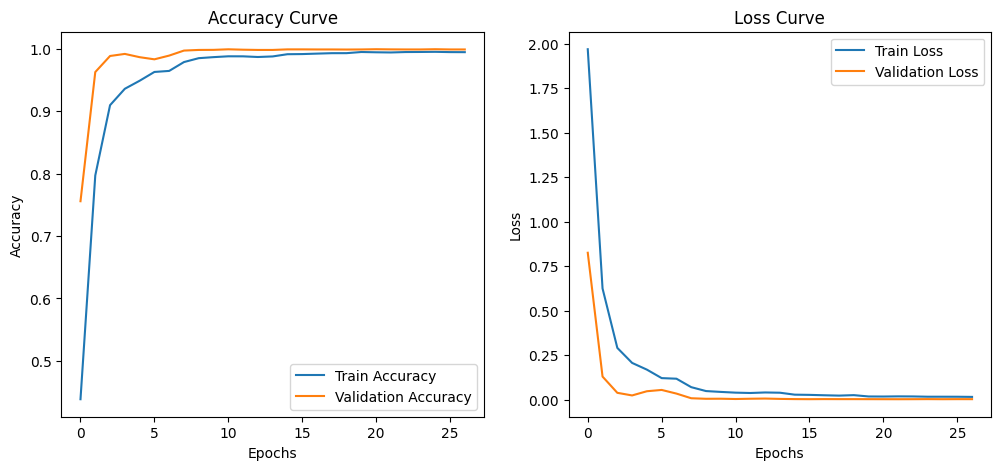

In [32]:
plt.figure(figsize=(12,5))

# Accuracy
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy Curve')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Loss
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss Curve')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.show()

In [33]:
plot_model(model, to_file='cnn_architecture.png', show_shapes=True, show_layer_names=True)
test_loss, test_acc = model.evaluate(X_test_cnn, y_test)
print("CNN Test Accuracy:", test_acc)

1226/1226 ━━━━━━━━━━━━━━━━━━━━ 19s 15ms/step - accuracy: 0.9998 - loss: 9.0245e-04
CNN Test Accuracy: 0.9998214840888977


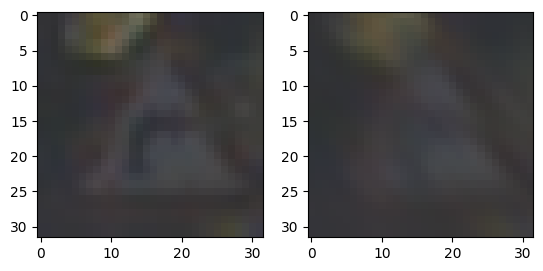

In [34]:
import cv2

def apply_custom_kernel(image, kernel_matrix):
    kernel = np.array(kernel_matrix, dtype=np.float32)
    return cv2.filter2D(image, -1, kernel)

motion_blur_kernel = [
    [0.2, 0, 0, 0, 0],
    [0, 0.2, 0, 0, 0],
    [0, 0, 0.2, 0, 0],
    [0, 0, 0, 0.2, 0],
    [0, 0, 0, 0, 0.2]
]

new_img = apply_custom_kernel(X_train[0],motion_blur_kernel)
plt.subplot(121)
plt.imshow(X_train[0])
plt.subplot(122)
plt.imshow(new_img)

In [35]:
def add_noise(data):
    noised_data = []
    for img in data:
        noised_data.append(np.clip(apply_custom_kernel(img,motion_blur_kernel),0,255).astype(np.uint8))
    return np.array(noised_data)

In [36]:
y_train_denoise = X_train.copy()
x_train_denoise = add_noise(y_train_denoise)
x_train_denoise = x_train_denoise/255
y_train_denoise = y_train_denoise/255
x_train_denoise = x_train_denoise.reshape(-1,32,32,3)
y_train_denoise = y_train_denoise.reshape(-1,32,32,3)

In [37]:
autoencoder_model =  Sequential([
    Conv2D(32, (3,3), padding="same",input_shape=(32,32,3)),
    BatchNormalization(),
    LeakyReLU(alpha=0.2),
    MaxPooling2D((2,2),strides=2),
    Conv2D(64, (3,3),padding="same"),
    BatchNormalization(),
    LeakyReLU(alpha=0.2),
    Conv2D(64, (3,3),padding="same"),
    BatchNormalization(),
    LeakyReLU(alpha=0.2),
    MaxPooling2D(2,2),
    Conv2D(128, (3,3),padding="same"),
    BatchNormalization(),
    LeakyReLU(alpha=0.2),
    Conv2D(128, (3,3),padding="same"),
    BatchNormalization(),
    LeakyReLU(alpha=0.2),
    UpSampling2D(size=(2,2)),
    Conv2D(64, (3,3),padding="same"),
    BatchNormalization(),
    LeakyReLU(alpha=0.2),
    Conv2D(64, (3,3),padding="same"),
    BatchNormalization(),
    LeakyReLU(alpha=0.2),
    UpSampling2D(size=(2,2)),
    Conv2D(32, (3,3),padding="same"),
    BatchNormalization(),
    LeakyReLU(alpha=0.2),
    Conv2D(3, (3,3),activation="sigmoid",padding="same")
])
autoencoder_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_1 (LeakyReLU)       │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_2 (LeakyReLU)       │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_3 (LeakyReLU)       │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 8, 8, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_4 (LeakyReLU)       │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 16, 16, 64)     │        73,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_5 (LeakyReLU)       │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 16, 16, 64)     │        36,92

 Total params: 410,115 (1.56 MB)

 Trainable params: 408,963 (1.56 MB)

 Non-trainable params: 1,152 (4.50 KB)

In [ ]:
autoencoder_model.compile(optimizer="adam",loss="mse",metrics=["mae"])
history = autoencoder_model.fit(x_train_denoise,y_train_denoise,batch_size=32,epochs=20)

Epoch 1/20
1226/1226 ━━━━━━━━━━━━━━━━━━━━ 342s 274ms/step - loss: 0.0096 - mae: 0.0648
Epoch 2/20
1226/1226 ━━━━━━━━━━━━━━━━━━━━ 330s 269ms/step - loss: 0.0035 - mae: 0.0410
Epoch 3/20
1226/1226 ━━━━━━━━━━━━━━━━━━━━ 333s 271ms/step - loss: 0.0025 - mae: 0.0342
Epoch 4/20
 722/1226 ━━━━━━━━━━━━━━━━━━━━ 2:16 272ms/step - loss: 0.0021 - mae: 0.0311

In [ ]:
autoencoder_model.save("/kaggle/working/autoencoder_model.keras")

In [ ]:
print(f'number of classes: {len(np.unique(y_train))}')

## Pretrained vs fine-tuned
| Model State | Optimizer | Training Loss | Training Accuracy | Validation Loss | validation Accuracy |
| :--- | :--- | :--- | :--- | :--- | :--- |
| **Pretrained (Frozen)** | Adam | 0.1948 | 0.9325 | 0.8452  | 0.7967 |
| **Fine-tuned (Unfrozen)** | Adam | 0.0182  | 0.9944  | 0.2067  | 0.9618 |

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Conv2D, BatchNormalization, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

optimizers_to_test = {
    'SGD': tf.keras.optimizers.SGD(learning_rate=0.01, momentum=0.9),
    'Adam': tf.keras.optimizers.Adam(learning_rate=0.001),
    'RMSprop': tf.keras.optimizers.RMSprop(learning_rate=0.001)
}

histories = {}
results = {}

for opt_name, opt in optimizers_to_test.items():
    print(f"Training with {opt_name} ")

    m = Sequential([
        Input(shape=(32, 32, 3)),
        Conv2D(32, (3, 3), activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling2D((2, 2)),
        Conv2D(64, (3, 3), activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling2D((2, 2)),
        Conv2D(128, (3, 3), activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling2D((2, 2)),
        Flatten(),
        Dense(256, activation='relu'),
        Dropout(0.5),
        Dense(43, activation='softmax')
    ])

    m.compile(
        optimizer=opt,
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    early_stop = EarlyStopping(patience=5, restore_best_weights=True)
    reduce_lr = ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.3,
        patience=3,
        min_lr=1e-5
    )

    datagen = ImageDataGenerator(
        rotation_range=15,
        zoom_range=0.2,
        width_shift_range=0.15,
        height_shift_range=0.15,
        shear_range=0.1
    )

    datagen.fit(X_train_cnn)

    history = m.fit(
        datagen.flow(X_train_cnn, y_train, batch_size=64),
        epochs=30,
        validation_data=(X_val_cnn, y_val),
        callbacks=[early_stop, reduce_lr],
        verbose=1
    )

    loss, acc = m.evaluate(X_test_cnn, y_test, verbose=0)

    histories[opt_name] = history
    results[opt_name] = {
        'Test Accuracy': round(acc, 4),
        'Test Loss': round(loss, 4)
    }

    print(f"{opt_name} : Test Accuracy: {acc:.4f}")

# Training Curves
colors = {'SGD': 'red', 'Adam': 'blue', 'RMSprop': 'green'}
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
for name, h in histories.items():
    plt.plot(h.history['accuracy'], label=name, color=colors[name])
plt.title('Training Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
for name, h in histories.items():
    plt.plot(h.history['val_accuracy'], label=name, color=colors[name])
plt.title('Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.tight_layout()
plt.show()

# Metrics Table
rows = []
for name, h in histories.items():
    rows.append({
        'Optimizer': name,
        'Final Train Acc': round(h.history['accuracy'][-1], 4),
        'Final Val Acc': round(h.history['val_accuracy'][-1], 4),
        'Best Val Acc': round(max(h.history['val_accuracy']), 4),
        'Best Val Epoch': int(np.argmax(h.history['val_accuracy'])) + 1,
        'Test Accuracy': results[name]['Test Accuracy'],
        'Test Loss': results[name]['Test Loss'],
    })

df_optimizers = pd.DataFrame(rows).set_index('Optimizer')
print(df_optimizers)

# **RNN**

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense, Dropout
from tensorflow.keras.optimizers import Adam

def build_improved_rnn(input_shape, num_classes):
    model = Sequential()


    model.add(SimpleRNN(256, input_shape=input_shape, activation='relu', return_sequences=False))


    model.add(Dropout(0.2))

    model.add(Dense(128, activation='relu'))
    model.add(Dropout(0.2))

    model.add(Dense(num_classes, activation='softmax'))
    return model


model = build_improved_rnn((32, 32), 43)


optimizer = Adam(learning_rate=0.0001)

model.compile(optimizer=optimizer,
              loss='categorical_crossentropy',
              metrics=['accuracy'])

model.summary()

history = model.fit(
    X_train_final, y_train_cat,
    epochs=20,
    batch_size=64,
    validation_data=(X_test_final, y_test_cat)
)

In [ ]:
import matplotlib.pyplot as plt


plt.plot(history.history['accuracy'], label='train_acc')
plt.plot(history.history['val_accuracy'], label='val_acc')
plt.title('Model Accuracy')
plt.legend()
plt.show()


plt.plot(history.history['loss'], label='train_loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.title('Model Loss')
plt.legend()
plt.show()

# **LSTM**

In [20]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.utils import to_categorical
import pandas as pd

 
X_train_lstm = X_train.reshape(X_train.shape[0], 32, 96).astype('float32') / 255.0
X_test_lstm = X_test.reshape(X_test.shape[0], 32, 96).astype('float32') / 255.0

#1 hot encode labels 
y_train_cat = to_categorical(y_train, num_classes=43)
y_test_cat = to_categorical(y_test, num_classes=43)

#split validation test
from sklearn.model_selection import train_test_split
X_tr, X_val, y_tr, y_val_cat = train_test_split(
    X_train_lstm, y_train_cat, test_size=0.2, random_state=42
)

print("X_train shape:", X_tr.shape)
print("X_test shape: ", X_test_lstm.shape)


X_train shape: (31367, 32, 96)
X_test shape:  (39209, 32, 96)


In [21]:
#Building
lstm_model = Sequential([
    LSTM(128, input_shape=(32, 96), return_sequences=True),
    Dropout(0.3),

    LSTM(64, return_sequences=False),
    Dropout(0.3),

    Dense(128, activation='relu'),
    Dropout(0.3),

    Dense(43, activation='softmax')
])

lstm_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

lstm_model.summary()


2026-05-12 10:01:42.778414: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 32, 128)        │       115,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 43)             │         5,547 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 178,475 (697.17 KB)

 Trainable params: 178,475 (697.17 KB)

 Non-trainable params: 0 (0.00 B)

In [22]:
#training

early_stop = EarlyStopping(patience=5, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.3, patience=3, min_lr=1e-5)

history = lstm_model.fit(
    X_tr, y_tr,
    epochs=30,
    batch_size=64,
    validation_data=(X_val, y_val_cat),
    callbacks=[early_stop, reduce_lr],
    verbose=1
)


Epoch 1/30
491/491 ━━━━━━━━━━━━━━━━━━━━ 40s 74ms/step - accuracy: 0.1844 - loss: 2.9750 - val_accuracy: 0.5754 - val_loss: 1.2256 - learning_rate: 0.0010
Epoch 2/30
491/491 ━━━━━━━━━━━━━━━━━━━━ 36s 72ms/step - accuracy: 0.5863 - loss: 1.2570 - val_accuracy: 0.7474 - val_loss: 0.7637 - learning_rate: 0.0010
Epoch 3/30
491/491 ━━━━━━━━━━━━━━━━━━━━ 36s 72ms/step - accuracy: 0.7474 - loss: 0.7824 - val_accuracy: 0.8818 - val_loss: 0.3972 - learning_rate: 0.0010
Epoch 4/30
491/491 ━━━━━━━━━━━━━━━━━━━━ 36s 73ms/step - accuracy: 0.8499 - loss: 0.4936 - val_accuracy: 0.9320 - val_loss: 0.2430 - learning_rate: 0.0010
Epoch 5/30
491/491 ━━━━━━━━━━━━━━━━━━━━ 36s 73ms/step - accuracy: 0.9040 - loss: 0.3232 - val_accuracy: 0.9200 - val_loss: 0.2610 - learning_rate: 0.0010
Epoch 6/30
491/491 ━━━━━━━━━━━━━━━━━━━━ 36s 73ms/step - accuracy: 0.9216 - loss: 0.2667 - val_accuracy: 0.9529 - val_loss: 0.1597 - learning_rate: 0.0010
Epoch 7/30
491/491 ━━━━━━━━━━━━━━━━━━━━ 36s 74ms/step - accuracy: 0.9320 - l

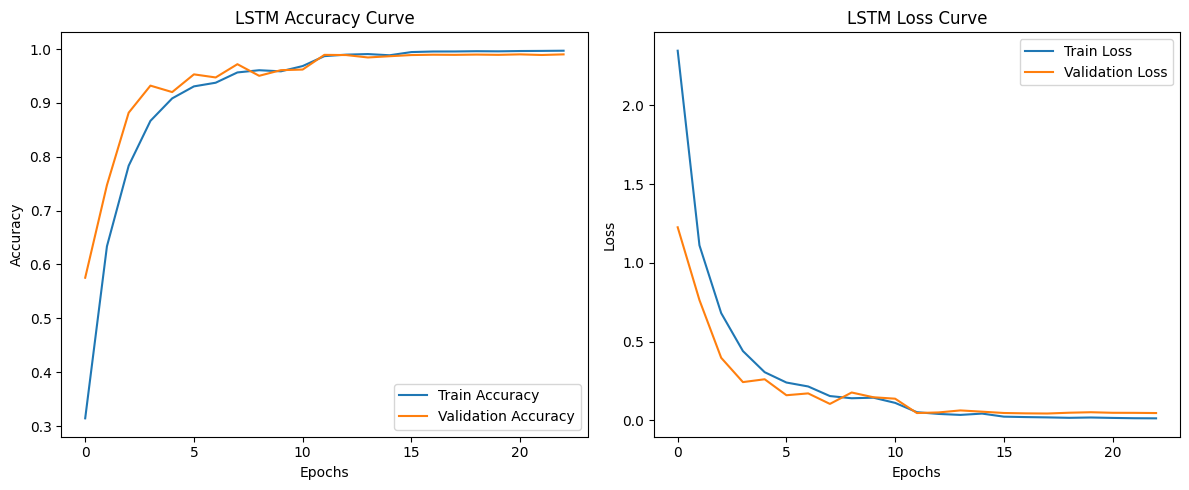

In [23]:
#plot training curve

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('LSTM Accuracy Curve')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('LSTM Loss Curve')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()


In [24]:
#evaluationn

test_loss, test_acc = lstm_model.evaluate(X_test_lstm, y_test_cat, verbose=0)
print(f"LSTM Test Accuracy: {test_acc:.4f}")
print(f"LSTM Test Loss: {test_loss:.4f}")


LSTM Test Accuracy: 0.9961
LSTM Test Loss: 0.0143
